## Loading Section

In [84]:
from pathlib import Path
from pprint import pprint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression


In [85]:
src_dir = Path.home() / "da_projects/workforce_forecasting_and_capacity_planning_analytics/data/processed"
daily_summary_file = "daily_summary.csv"
daily_workload_summary = pd.read_csv(src_dir / daily_summary_file, parse_dates=['date'])
pprint(daily_workload_summary.head())

        date    month  dow_num day_of_week  total_volume  \
0 2024-01-01  January        0      Monday          4079   
1 2024-01-02  January        1     Tuesday          3972   
2 2024-01-03  January        2   Wednesday          3342   
3 2024-01-04  January        3    Thursday          3179   
4 2024-01-05  January        4      Friday          3024   

   total_workload_hours  avg_aht  
0                468.61    488.6  
1                458.79    487.0  
2                380.71    479.6  
3                365.95    488.6  
4                349.18    487.8  


## Data Validation Section

In [86]:
pprint(daily_workload_summary.info())
print("\n")
pprint(daily_workload_summary.describe())

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  731 non-null    datetime64[us]
 1   month                 731 non-null    str           
 2   dow_num               731 non-null    int64         
 3   day_of_week           731 non-null    str           
 4   total_volume          731 non-null    int64         
 5   total_workload_hours  731 non-null    float64       
 6   avg_aht               731 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 40.1 KB
None


                      date     dow_num  total_volume  total_workload_hours  \
count                  731  731.000000    731.000000            731.000000   
mean   2024-12-31 00:00:00    2.991792   3383.701778            390.458044   
min    2024-01-01 00:00:00    0.000000   1373.000000            15

In [87]:
print("Missing values: ")
pprint(daily_workload_summary.isna().sum())
print("\nDuplicate values: ")
pprint(daily_workload_summary.duplicated().sum())
actual_volume = daily_workload_summary.drop(columns=['total_workload_hours', 'avg_aht'])

Missing values: 
date                    0
month                   0
dow_num                 0
day_of_week             0
total_volume            0
total_workload_hours    0
avg_aht                 0
dtype: int64

Duplicate values: 
np.int64(0)


## Forecasting section

### Moving Average Model

In [88]:
moving_average = actual_volume.assign(
    moving_average_forecast=lambda df: 
        df['total_volume'].shift(1).rolling(window=7).mean().round(2)
)
pprint(moving_average.head())
pprint(moving_average.tail())

        date    month  dow_num day_of_week  total_volume  \
0 2024-01-01  January        0      Monday          4079   
1 2024-01-02  January        1     Tuesday          3972   
2 2024-01-03  January        2   Wednesday          3342   
3 2024-01-04  January        3    Thursday          3179   
4 2024-01-05  January        4      Friday          3024   

   moving_average_forecast  
0                      NaN  
1                      NaN  
2                      NaN  
3                      NaN  
4                      NaN  
          date     month  dow_num day_of_week  total_volume  \
726 2025-12-27  December        5    Saturday          3125   
727 2025-12-28  December        6      Sunday          2262   
728 2025-12-29  December        0      Monday          5071   
729 2025-12-30  December        1     Tuesday          5047   
730 2025-12-31  December        2   Wednesday          4811   

     moving_average_forecast  
726                  4114.57  
727                  409

In [89]:
training_start_date = pd.to_datetime('2024-01-01')
training_end_date = pd.to_datetime('2025-09-30')
testing_start_date = pd.to_datetime('2025-10-01')
testing_end_date = pd.to_datetime('2025-12-31')
training_data = moving_average.loc[
    actual_volume['date'].between(training_start_date, training_end_date)
]
testing_data = moving_average.loc[
    actual_volume['date'].between(testing_start_date, testing_end_date)
]
print("Training data sample: ")
pprint(training_data.head(7))
print("\n")
print("Testing data sample: ")
pprint(testing_data.head(7))

Training data sample: 
        date    month  dow_num day_of_week  total_volume  \
0 2024-01-01  January        0      Monday          4079   
1 2024-01-02  January        1     Tuesday          3972   
2 2024-01-03  January        2   Wednesday          3342   
3 2024-01-04  January        3    Thursday          3179   
4 2024-01-05  January        4      Friday          3024   
5 2024-01-06  January        5    Saturday          2288   
6 2024-01-07  January        6      Sunday          1687   

   moving_average_forecast  
0                      NaN  
1                      NaN  
2                      NaN  
3                      NaN  
4                      NaN  
5                      NaN  
6                      NaN  


Testing data sample: 
          date    month  dow_num day_of_week  total_volume  \
639 2025-10-01  October        2   Wednesday          3824   
640 2025-10-02  October        3    Thursday          4000   
641 2025-10-03  October        4      Friday          

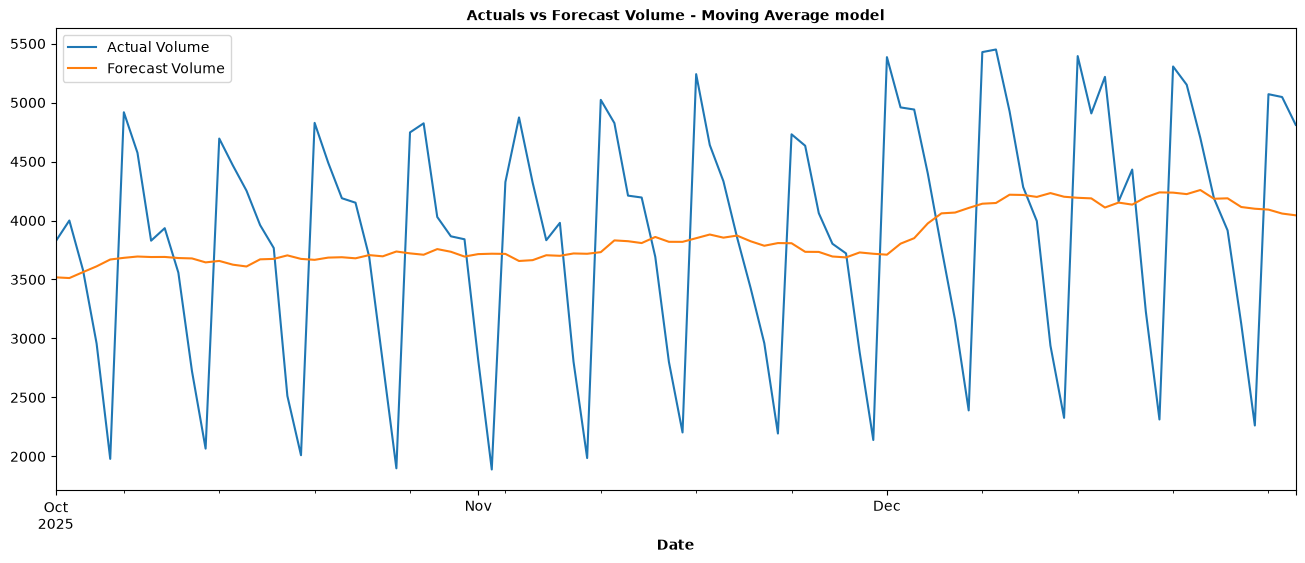

In [90]:
testing_data.plot(
    x='date',
    y=['total_volume', 'moving_average_forecast'],
    figsize=(16, 6)
)
plt.title('Actuals vs Forecast Volume - Moving Average model', fontsize=10, fontweight='bold')
plt.legend(['Actual Volume', 'Forecast Volume'])
plt.xlabel('Date', fontweight='bold')
plt.show()

In [ ]:
moving_average_errors = {
    "model": "moving_average_forecast",
    "mae": round(
        (testing_data['total_volume'] - testing_data['moving_average_forecast'])
        .abs()
        .mean()
    , 2),
    "rmse": round(
        np.sqrt(
            (
                (testing_data['total_volume'] - testing_data['moving_average_forecast']) ** 2
            )
            .mean()
        )
    , 2),
    "mape": round(
        (
            (
                (testing_data['total_volume'] - testing_data['moving_average_forecast']).abs() /
                testing_data['total_volume']
            )
            .mean() * 100
        )
    , 2)
}
pprint(moving_average_errors)

{'mae': np.float64(818.2),
 'mape': np.float64(25.53),
 'model': 'moving_average_forecast',
 'rmse': np.float64(981.68)}


### Holt-Winters Model

In [92]:
model = ExponentialSmoothing(
    endog=training_data['total_volume'],
    trend="mul",
    seasonal="mul",
    seasonal_periods=7
)
model_fit = model.fit()
testing_data['holt_winters_forecast'] = model_fit.forecast(steps=92).round(2)
pprint(testing_data.head())

          date    month  dow_num day_of_week  total_volume  \
639 2025-10-01  October        2   Wednesday          3824   
640 2025-10-02  October        3    Thursday          4000   
641 2025-10-03  October        4      Friday          3581   
642 2025-10-04  October        5    Saturday          2957   
643 2025-10-05  October        6      Sunday          1979   

     moving_average_forecast  holt_winters_forecast  
639                  3518.14                4093.96  
640                  3512.14                3862.62  
641                  3562.43                3495.15  
642                  3611.43                2720.56  
643                  3669.43                1937.81  


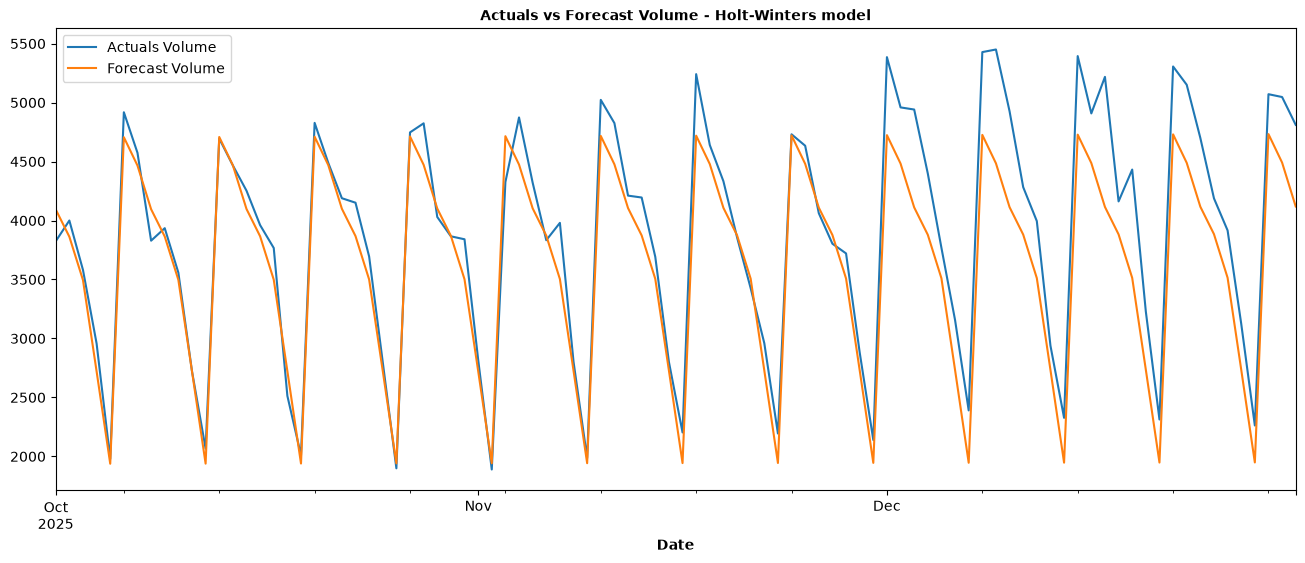

In [93]:
testing_data.plot(
    x='date',
    y=['total_volume', 'holt_winters_forecast'],
    figsize=(16, 6)
)
plt.title('Actuals vs Forecast Volume - Holt-Winters model', fontsize=10, fontweight='bold')
plt.legend(['Actuals Volume', 'Forecast Volume'])
plt.xlabel('Date', fontweight='bold')
plt.show()

In [94]:
holt_winters_errors = {
    "model": "holt_winters",
    "mae": round(
        (testing_data['total_volume'] - testing_data['holt_winters_forecast'])
        .abs()
        .mean()
    , 2),
    "rmse": round(
        np.sqrt(
            (
                (testing_data['total_volume'] - testing_data['holt_winters_forecast']) ** 2
            )
            .mean()
        )
    , 2),
    "mape": round(
        (
            (
                (testing_data['total_volume'] - testing_data['holt_winters_forecast']).abs() / 
                testing_data['total_volume']
            )
            .mean() * 100
        )
    , 2)
}
pprint(holt_winters_errors)

{'mae': np.float64(286.92),
 'mape': np.float64(7.2),
 'model': 'holt_winters',
 'rmse': np.float64(374.37)}


### Linear Regression Model

In [96]:
regression_analysis = actual_volume.assign(
    day_index =lambda df: range(len(df))
).drop(columns=["dow_num"])
one_hot_encoded = pd.get_dummies(
    regression_analysis,
    prefix=["dow", "month"],
    columns=["day_of_week", "month"]
)
regression_training_data = one_hot_encoded.loc[
    one_hot_encoded['date'].between(training_start_date, training_end_date)
]
regression_test_data = one_hot_encoded.loc[
    one_hot_encoded['date'].between(testing_start_date, testing_end_date)
]
print(len(regression_training_data))
print(len(regression_test_data))

639
92


In [98]:
features_training = regression_training_data.drop(
    columns=['date', 'total_volume']
)
target_training = regression_training_data['total_volume']
features_test = regression_test_data.drop(
    columns=['date', 'total_volume']
)
target_test = regression_test_data['total_volume']

model = LinearRegression()
model_fit = model.fit(features_training, target_training)
predictions = pd.Series(model.predict(features_test).round(2), index=features_test.index)

testing_data['linear_regression_forecast'] = predictions

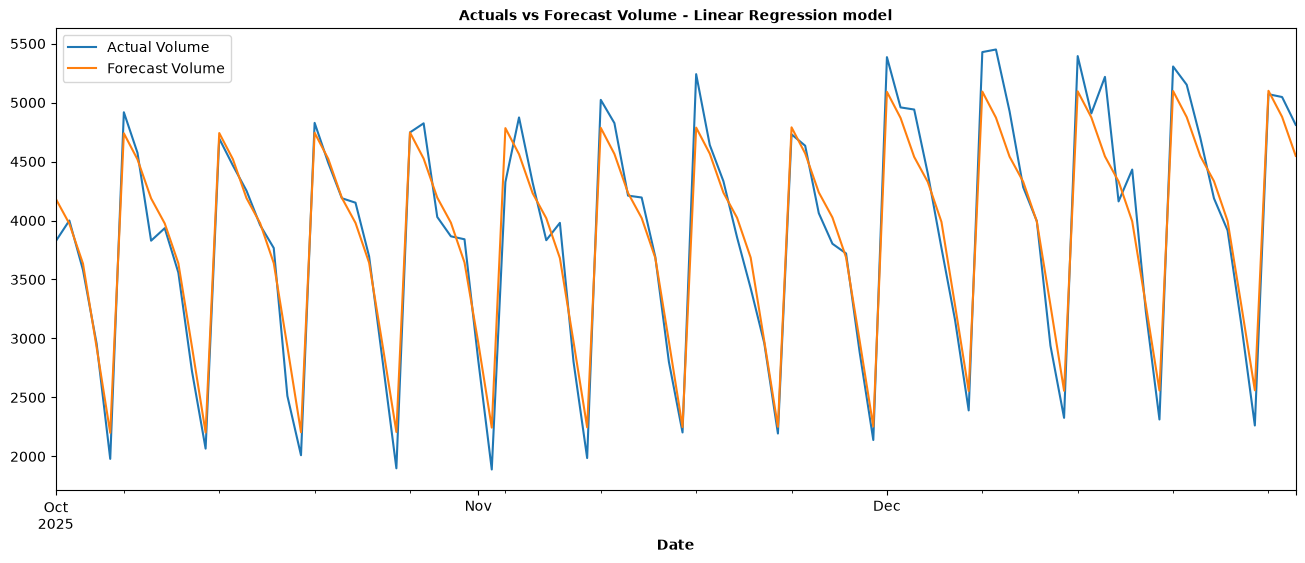

In [99]:
testing_data.plot(
    x='date',
    y=['total_volume', 'linear_regression_forecast'],
    figsize=(16, 6)
)
plt.title('Actuals vs Forecast Volume - Linear Regression model', fontsize=10, fontweight='bold')
plt.xlabel('Date', fontweight='bold')
plt.legend(['Actual Volume', 'Forecast Volume'])
plt.show()

In [100]:
linear_regression_errors = {
    "model": "linear_regression",
    "mae": round(
        (testing_data['total_volume'] - testing_data['linear_regression_forecast'])
        .abs()
        .mean()
    , 2),
    "rmse": round(
        np.sqrt(
            (
                (testing_data['total_volume'] - testing_data['linear_regression_forecast']) ** 2
            )
            .mean()
        )
    , 2),
    "mape": round(
        (
            (
                (testing_data['total_volume'] - testing_data['linear_regression_forecast']).abs() / 
                testing_data['total_volume']
            )
            .mean() * 100
        )
    , 2)
}
pprint(linear_regression_errors)

{'mae': np.float64(177.21),
 'mape': np.float64(4.97),
 'model': 'linear_regression',
 'rmse': np.float64(223.8)}


## Models Evaluation Section

In [101]:
models_info = [moving_average_errors, holt_winters_errors, linear_regression_errors]
model_comparison_df = pd.DataFrame(models_info)
model_comparison_df['rank'] = model_comparison_df['mape'].rank(method='dense').astype(int)
model_comparison_df = model_comparison_df.sort_values(by='rank')
pprint(model_comparison_df.head())

                     model     mae    rmse   mape  rank
2        linear_regression  177.21  223.80   4.97     1
1             holt_winters  286.92  374.37   7.20     2
0  moving_average_forecast  818.20  981.68  25.53     3


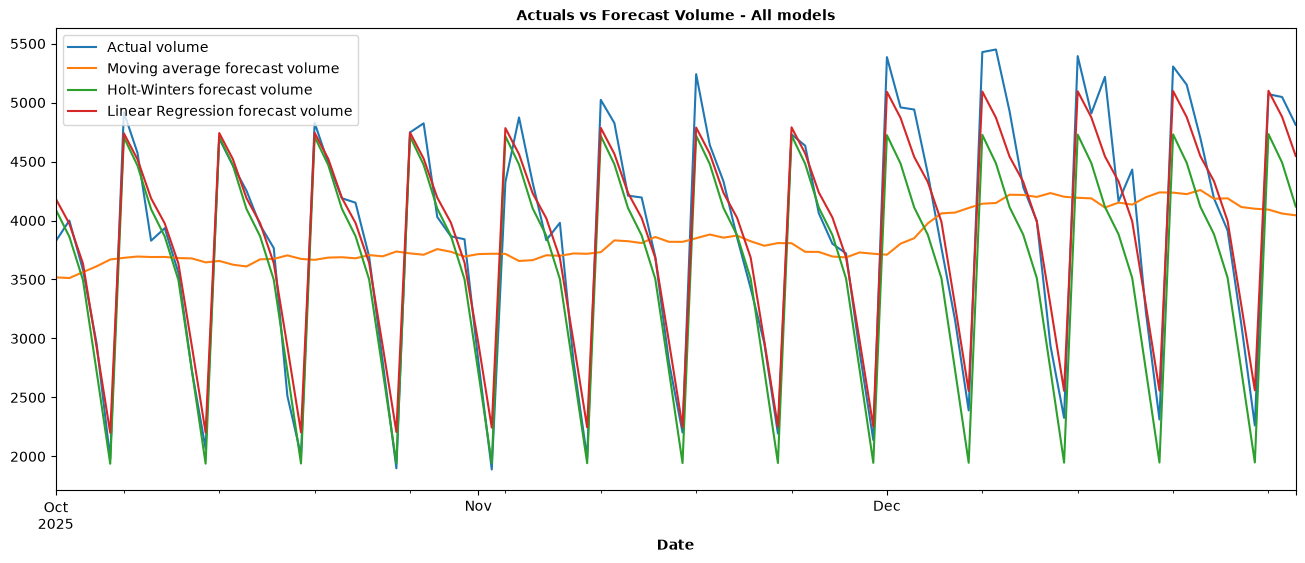

In [102]:
testing_data.plot(
    x='date',
    y=[
        'total_volume', 
        'moving_average_forecast', 
        'holt_winters_forecast', 
        'linear_regression_forecast'
    ],
    figsize=(16, 6)
)
plt.title('Actuals vs Forecast Volume - All models', fontsize=10, fontweight='bold')
plt.xlabel('Date', fontweight='bold')
plt.legend([
    'Actual volume', 
    'Moving average forecast volume',
    'Holt-Winters forecast volume',
    'Linear Regression forecast volume'
])
plt.show()

## Future Forecast Generation Section

In [103]:
actual_volume['day_index'] = range(len(daily_workload_summary))
forecast_start = pd.to_datetime('2026-01-01')
forecast_end = pd.to_datetime('2026-12-31')

actuals_last_day_index = actual_volume['day_index'].max() + 1

forecast_data = (
    pd.date_range(start=forecast_start, end=forecast_end)
    .to_frame(index=False, name="date")
    .assign(
        day_index=lambda df: range(len(df)) + actuals_last_day_index,
        dow_num=lambda df: df["date"].dt.dayofweek,
        day_of_week=lambda df: df["date"].dt.day_name(),
        month=lambda df: df["date"].dt.month_name(),
    )
)
pprint(forecast_data.head())
pprint(forecast_data.tail())

        date  day_index  dow_num day_of_week    month
0 2026-01-01        731        3    Thursday  January
1 2026-01-02        732        4      Friday  January
2 2026-01-03        733        5    Saturday  January
3 2026-01-04        734        6      Sunday  January
4 2026-01-05        735        0      Monday  January
          date  day_index  dow_num day_of_week     month
360 2026-12-27       1091        6      Sunday  December
361 2026-12-28       1092        0      Monday  December
362 2026-12-29       1093        1     Tuesday  December
363 2026-12-30       1094        2   Wednesday  December
364 2026-12-31       1095        3    Thursday  December


In [104]:
actuals_period = actual_volume.drop(columns=["dow_num"])
forecast_period = forecast_data[['date', 'day_index', 'day_of_week', 'month']]

encoded_actuals = pd.get_dummies(
    actuals_period,
    prefix=["dow", "month"],
    columns=["day_of_week", "month"]
)
actuals_features = encoded_actuals.drop(
    columns=['date', 'total_volume']
)
actuals_target = encoded_actuals['total_volume']
encoded_forecast = pd.get_dummies(
    forecast_period,
    prefix=["dow", "month"],
    columns=["day_of_week", "month"]
)
forecast_features = encoded_forecast.drop(
    columns=['date']
)

model = LinearRegression()
model_fit = model.fit(actuals_features, actuals_target)
predictions = pd.Series(model.predict(forecast_features).round(2), index=forecast_features.index)

forecast_data['forecast'] = predictions
pprint(forecast_data.head(7))

        date  day_index  dow_num day_of_week    month  forecast
0 2026-01-01        731        3    Thursday  January   3518.03
1 2026-01-02        732        4      Friday  January   3190.71
2 2026-01-03        733        5    Saturday  January   2457.71
3 2026-01-04        734        6      Sunday  January   1725.57
4 2026-01-05        735        0      Monday  January   4303.93
5 2026-01-06        736        1     Tuesday  January   4089.03
6 2026-01-07        737        2   Wednesday  January   3748.59


## Future Forecast Visualization Section

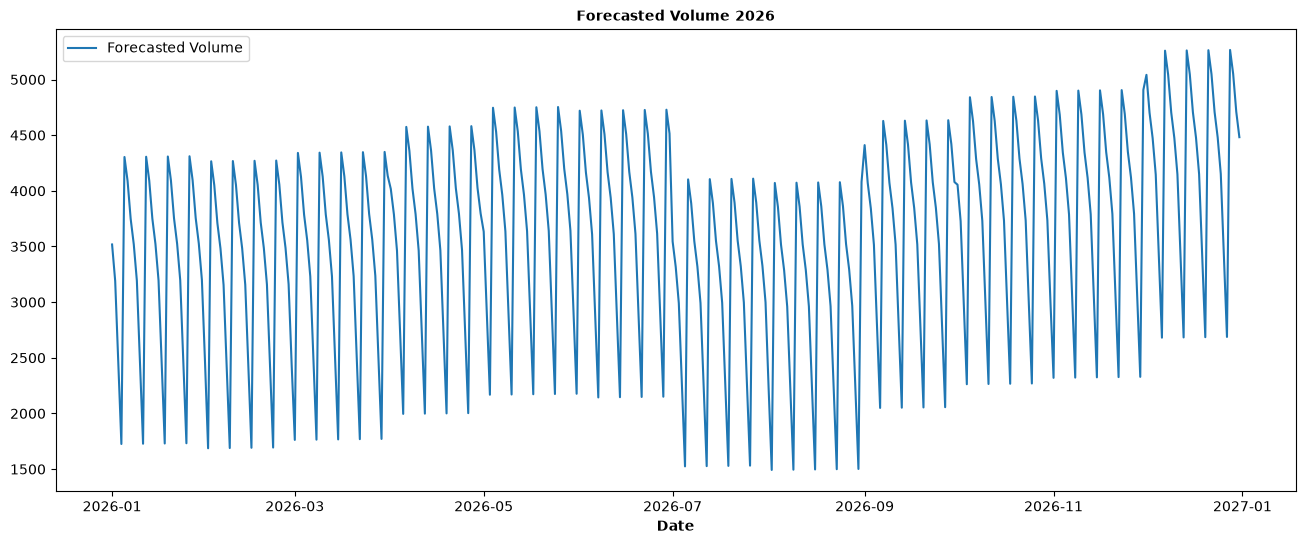

In [109]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(forecast_data['date'], forecast_data['forecast'], label='Forecasted Volume')
ax.set_title('Forecasted Volume 2026', fontsize=10, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.legend()
plt.show()

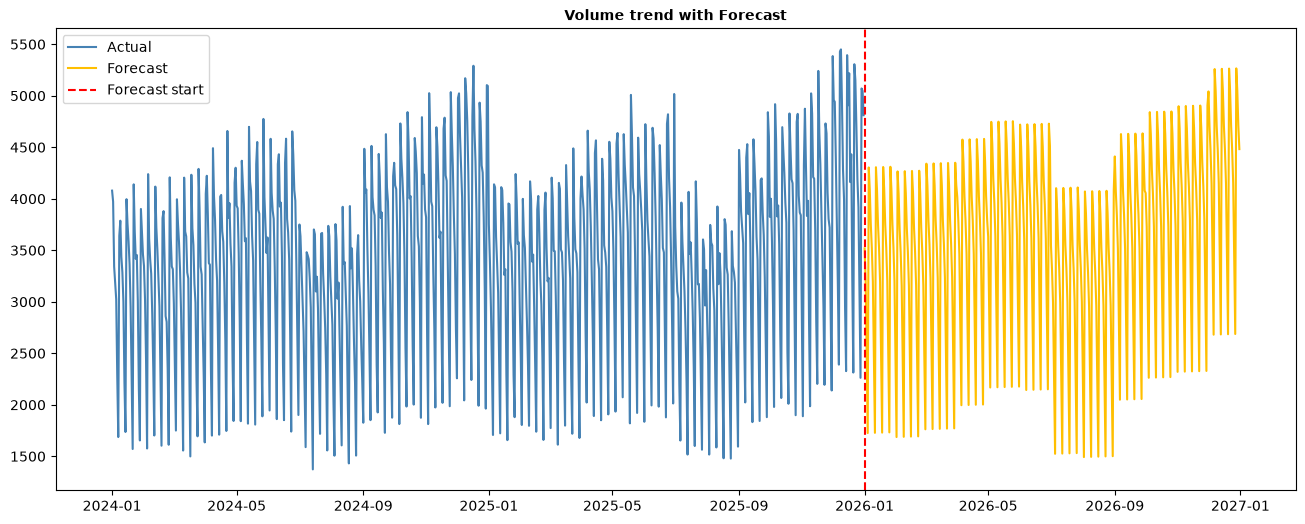

In [106]:
cutoff_date = pd.to_datetime('2026-01-01')
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_workload_summary['date'], daily_workload_summary['total_volume'], color='steelblue', label='Actual')
ax.plot(forecast_data['date'], forecast_data['forecast'], color='#FFBF00', label='Forecast')
ax.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=1.5, label='Forecast start')
ax.set_title("Volume trend with Forecast", fontsize=10, fontweight='bold')
ax.legend()
plt.show()

## Exports section

In [108]:
output_dir = Path.home() / 'da_projects/workforce_forecasting_and_capacity_planning_analytics/data/forecasts'

forecast_comparison_file = 'forecast_comparison.csv'
(
    testing_data
    .drop(columns=['month', 'dow_num', 'day_of_week'])
    .rename(columns={'total_volume': 'actual_volume'})
    .to_csv(output_dir / forecast_comparison_file, index=False)
)

forecast_accuracy_summary_file = 'forecast_accuracy_summary.csv'
model_comparison_df.to_csv(output_dir / forecast_accuracy_summary_file, index=False)

forecast_file = 'forecasted_volumes.csv'
forecast_data.to_csv(output_dir / forecast_file, index=False)

## Forecasting Conclusions

1. Three forecasting approaches were evaluated: a 7-Day Moving Average model, a Holt-Winters Exponential Smoothing model, and a Linear Regression model.

2. Model performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) on an out-of-sample test period covering October 2025 through December 2025.

3. The Linear Regression model achieved the highest forecasting accuracy, recording a MAPE of 4.97%, outperforming both the Holt-Winters model (7.20%) and the 7-Day Moving Average model (25.53%).

4. The superior performance of the Linear Regression model indicates that workload demand is strongly influenced by calendar-based factors such as long-term trend, day-of-week seasonality, and monthly seasonality.

5. Forecast accuracy below 5% suggests that the selected model is highly effective at capturing the underlying demand patterns present within the synthetic workforce dataset.

6. Based on model evaluation results, the Linear Regression model was selected as the production forecasting model and retrained using the complete historical dataset covering January 2024 through December 2025.

7. The selected model was used to generate daily workload forecasts for the period January 2026 through December 2026, providing a forward-looking demand view to support workforce planning and capacity management activities.

8. Forecast outputs generated during this phase will serve as the primary input for the Capacity Planning phase, where forecasted workload volumes will be converted into workload hours, staffing requirements, shrinkage-adjusted FTE requirements, and staffing gap analyses.
